In [54]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset
# %matplotlib inline



In [55]:
df1=pd.read_csv(r"inputdata/EVUsersChargingData-high.csv")
df2=pd.read_csv(r"inputdata/EVUsersChargingData-low.csv")
df=pd.concat([df1, df2], ignore_index=True)

In [56]:
df.head()

,No.,ArriveTime,DepartTime,Duration/min,ArriveSOC,DepartSOC,BatteryCapacity/kWh,Fast-chargingWillingness,DischargingWillingness,AverageChargingPower
0,1,05:27,06:27,60,0.4800,0.9,50,1,0.123598,21.000000
1,2,05:44,06:30,46,0.4440,0.9,40,1,0.457124,23.791304
2,3,05:47,06:47,60,0.4957,0.9,40,1,0.281148,16.170000
3,4,06:05,06:52,47,0.4367,0.9,40,1,0.287219,23.655319
4,5,06:07,08:48,161,0.4867,0.9,60,1,0.261950,9.242236


In [57]:

df.tail()

,No.,ArriveTime,DepartTime,Duration/min,ArriveSOC,DepartSOC,BatteryCapacity/kWh,Fast-chargingWillingness,DischargingWillingness,AverageChargingPower
1995,996,21:30,23:59,149,0.4880,0.9,40,1,0.634238,6.636242
1996,997,21:33,23:45,132,0.4707,0.9,60,1,0.466063,11.707727
1997,998,22:27,23:12,45,0.4727,0.9,40,1,0.069011,22.792000
1998,999,22:35,02:27,232,0.4966,0.9,50,1,0.535844,5.216379
1999,1000,23:16,03:40,264,0.4411,0.9,40,1,0.637081,4.171818


In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   No.                       2000 non-null   int64  
 1   ArriveTime                2000 non-null   object 
 2   DepartTime                2000 non-null   object 
 3   Duration/min              2000 non-null   int64  
 4   ArriveSOC                 2000 non-null   float64
 5   DepartSOC                 2000 non-null   float64
 6   BatteryCapacity/kWh       2000 non-null   int64  
 7   Fast-chargingWillingness  2000 non-null   int64  
 8   DischargingWillingness    2000 non-null   float64
 9   AverageChargingPower      2000 non-null   float64
dtypes: float64(4), int64(4), object(2)
memory usage: 156.4+ KB


In [59]:
def time_to_float(t):
    hour, minute = map(int, t.split(":"))
    return hour + minute / 60



df['ArriveTime_float'] = df['ArriveTime'].apply(time_to_float)
df['DepartTime_float'] = df['DepartTime'].apply(time_to_float)

# Encode cyclic time
df['Arrive_sin'] = np.sin(2 * np.pi * df['ArriveTime_float'] / 24)
df['Arrive_cos'] = np.cos(2 * np.pi * df['ArriveTime_float'] / 24)
df['Depart_sin'] = np.sin(2 * np.pi * df['DepartTime_float'] / 24)
df['Depart_cos'] = np.cos(2 * np.pi * df['DepartTime_float'] / 24)

features=["Arrive_sin","Arrive_cos","Depart_sin",'Depart_cos',"Duration/min","ArriveSOC","DepartSOC","BatteryCapacity/kWh","Fast-chargingWillingness","DischargingWillingness"]
target=["AverageChargingPower"]

df_features=df[features]
df_target=df[target]


In [60]:
X_train, X_test, y_train, y_test = train_test_split(df_features, df_target, test_size=0.2, random_state=42)


# Normalize features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
# Convert to PyTorch tensors
# Convert to PyTorch tensors
# X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32).unsqueeze(1)  # Add channel dimension
# X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32).unsqueeze(1)
#
# y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)
# y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1)
if len(y_train.shape) == 1:
    y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)
else:
    # Already has shape [N, 1]
    y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32)

# Same for test
if len(y_test.shape) == 1:
    y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1)
else:
    y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32)
batch_size = 32
train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=batch_size, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=batch_size)



In [61]:
# #Create model class that inherits nn.Module
#
# class CNN1DRegression(nn.Module):
#     #input layer(4 features of the flower) -->
#     #  hidden layer1 (H1) (some neurons)-->
#     # hidden layer2 (H2) -->
#     # output(3 classes of iris flower)
#
#     def __init__(self,input_features=8,output_classes=1,sequence_length=100):
#         super(CNN1DRegression, self).__init__()
#         self.conv1 = nn.Conv1d(in_channels=input_features, out_channels=16, kernel_size=3)
#         self.relu1 = nn.ReLU()
#         self.pool1 = nn.MaxPool1d(kernel_size=2)
#
#         self.conv2 = nn.Conv1d(in_channels=16, out_channels= 32, kernel_size=3)
#         self.relu2 = nn.ReLU()
#         self.pool2 = nn.MaxPool1d(kernel_size=2)
#
#         with torch.no_grad():
#             dummy_input = torch.randn(1, input_features, sequence_length)
#             dummy_output = self.pool1(self.relu1(self.conv1(dummy_input)))
#             dummy_output = self.pool2(self.relu2(self.conv2(dummy_output)))
#             flattened_size = dummy_output.view(dummy_output.size(0), -1).shape[1]
#
#         self.flatten = nn.Flatten()
#         self.fc1 = nn.Linear(32 * flattened_size, 64)  # Replace computed_size with output shape after conv+pool
#         self.fc2 = nn.Linear(64, 1)  # 1 regression output
#
#
#
#     def forward(self,x):
#         x = self.pool1(self.relu1(self.conv1(x)))
#         x = self.pool2(self.relu2(self.conv2(x)))
#         x = self.flatten(x)
#         x = self.fc1(x)
#         output = self.fc2(x)  # No activation: linear output
#         return output
#
#


In [64]:

input_channels = X_train_tensor.shape[1]
sequence_length = X_train_tensor.shape[2]

class CNN1DRegression(nn.Module):
    def __init__(self, input_features=input_channels, output_classes=1, sequence_length=sequence_length):
        super(CNN1DRegression, self).__init__()

        # ✅ Conv1d expects: (batch, channels, sequence_length)
        # You are treating "features" as channels → input comes in shape (batch, channels=input_features, seq_len)

        self.conv1 = nn.Conv1d(in_channels=input_features, out_channels=16, kernel_size=3)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool1d(kernel_size=2)

        self.conv2 = nn.Conv1d(in_channels=16, out_channels=32, kernel_size=3)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool1d(kernel_size=2)

        # Dynamically compute the size after conv + pool
        with torch.no_grad():
            dummy_input = torch.randn(1, input_features, sequence_length)
            dummy_output = self.pool1(self.relu1(self.conv1(dummy_input)))
            dummy_output = self.pool2(self.relu2(self.conv2(dummy_output)))
            flattened_size = dummy_output.view(1, -1).shape[1]  # Final size for linear layer

        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(flattened_size, 64)
        self.fc2 = nn.Linear(64, output_classes)  # Single regression output

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = self.flatten(x)
        x = self.fc1(x)
        output = self.fc2(x)
        return output

In [73]:
#pick random seed for reproducibility
torch.manual_seed(0)
model = CNN1DRegression()


10
1


In [66]:
#set criteria of model to measure error.. how far off the prediction are from data
criterion = nn.MSELoss()
#choose optimizer we use Adam Optimizer
#learning rate (if error doesn't go down after bunch of epochs we might want to lower the learning rate)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [67]:
#train model
#decide how many epochs we want to train the model

# for i in range(epoch):
#     #forward pass and get predictions
#     y_pred = model.forward(X_train)
#     #measure loss
#     loss = criterion(y_pred, y_train) #it calculates the error between predicted and actual labels
#     #keep track of losses
#     losses.append(loss.detach().numpy())
#     #print loss every 10 epochs
#     if i % 10 == 0:
#         print(f'Epoch {i} Loss: {loss}')
#     #do backpropagation: take error of forward pass and feed it back to model to fine tune the weights
#     optimizer.zero_grad() #clear previous gradients
#     loss.backward() #calculate gradients
#     optimizer.step() #update weights based on gradients

losses = []
epochs = 100

for epoch in range(epochs):
    model.train()
    epoch_loss = 0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        output = model(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    losses.append(avg_loss)

    print(f"Epoch {epoch+1}/{epochs} - Loss: {avg_loss:.4f}")

Epoch 1/100 - Loss: 51.4646
Epoch 2/100 - Loss: 15.5860
Epoch 3/100 - Loss: 8.2876
Epoch 4/100 - Loss: 3.3872
Epoch 5/100 - Loss: 2.2098
Epoch 6/100 - Loss: 1.6607
Epoch 7/100 - Loss: 1.4422
Epoch 8/100 - Loss: 1.2447
Epoch 9/100 - Loss: 1.0223
Epoch 10/100 - Loss: 0.8803
Epoch 11/100 - Loss: 0.8989
Epoch 12/100 - Loss: 1.0548
Epoch 13/100 - Loss: 1.8116
Epoch 14/100 - Loss: 1.0382
Epoch 15/100 - Loss: 0.8379
Epoch 16/100 - Loss: 0.7698
Epoch 17/100 - Loss: 0.9612
Epoch 18/100 - Loss: 1.2110
Epoch 19/100 - Loss: 0.6753
Epoch 20/100 - Loss: 0.6798
Epoch 21/100 - Loss: 0.6200
Epoch 22/100 - Loss: 0.4762
Epoch 23/100 - Loss: 0.6059
Epoch 24/100 - Loss: 0.5329
Epoch 25/100 - Loss: 1.0107
Epoch 26/100 - Loss: 0.5582
Epoch 27/100 - Loss: 0.4417
Epoch 28/100 - Loss: 0.7572
Epoch 29/100 - Loss: 0.4331
Epoch 30/100 - Loss: 0.4409
Epoch 31/100 - Loss: 0.7001
Epoch 32/100 - Loss: 0.7288
Epoch 33/100 - Loss: 0.5503
Epoch 34/100 - Loss: 0.4554
Epoch 35/100 - Loss: 0.6558
Epoch 36/100 - Loss: 0.4156

Text(0, 0.5, 'Loss')

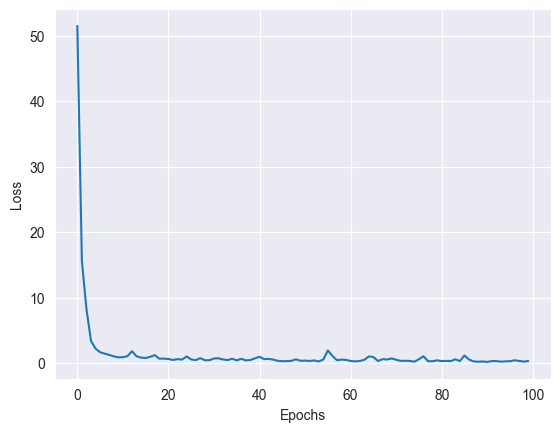

In [69]:
#graph
plt.plot(range(epochs), losses)
plt.xlabel('Epochs')
plt.ylabel('Loss')

In [70]:
# #evaluate model
# # Set model to evaluation mode
# model.eval()
#
# # Disable gradient computation
# with torch.no_grad():
#     y_pred = model(X_test).cpu().numpy()  # convert to NumPy
#     y_true = y_test.cpu().numpy()


In [71]:
model.eval()

y_preds = []
y_trues = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        y_pred = model(X_batch)
        y_preds.append(y_pred.cpu().numpy())
        y_trues.append(y_batch.cpu().numpy())

# Concatenate all batches
y_pred = np.concatenate(y_preds, axis=0)
y_true = np.concatenate(y_trues, axis=0)


In [72]:
#EVALUATING MODEL

# Compute metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Print results
print(f"📊 Evaluation Metrics:")
print(f"MAE  (Mean Absolute Error): {mae:.4f}")
print(f"MSE  (Mean Squared Error): {mse:.4f}")
print(f"RMSE (Root MSE):            {rmse:.4f}")
print(f"R²   (R-squared):           {r2:.4f}")

📊 Evaluation Metrics:
MAE  (Mean Absolute Error): 0.4698
MSE  (Mean Squared Error): 0.3670
RMSE (Root MSE):            0.6058
R²   (R-squared):           0.9935
